In [1]:
%matplotlib inline

import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline", force=True)

import matplotlib.pyplot as plt
from IPython.display import display

import torch
import numpy as np
from PIL import Image

from deeplens.geolens import GeoLens
from deeplens.geometric_surface import Aspheric, Aperture, Plane
from deeplens.diffractive_surface import DoeRaywavePlane
from deeplens.light import Ray

from src_lightweight.vis import img_crop

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
phase_profile_path = "demo2_smile_phase_profile.npy" # Run demo2_gt.py to generate the npy file

/opt/conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
wvln_um = 0.7

# hologram setup
slm_pixel_pitch = 0.0063
slm_phase_profile = torch.from_numpy(np.load(phase_profile_path)).to(device)
slm_res = slm_phase_profile.shape[0]
slm_radius = slm_res // 2 * slm_pixel_pitch

xy_slm = torch.arange(-slm_radius, slm_radius, slm_pixel_pitch, device=device)
X_slm, Y_slm = torch.meshgrid(xy_slm, xy_slm, indexing='xy')

slm_phase_profile = torch.flip(slm_phase_profile, dims=[0, 1])
slm_amplitude = ((X_slm**2 + Y_slm**2) < slm_radius**2).to(device)
slm_profile = slm_amplitude * torch.exp(1j * slm_phase_profile)

# sensor
f_num = 4
d_sensor = f_num * slm_radius

# ==============================
# Surface 0: Aperture, same as surface 1
# ==============================
aperture = Aperture(
    r=slm_radius,  
    d=0.0,
    device=device,
)

# ==============================
# Surface 1: Holography implement by raywave tracing full-field
# ==============================
slm = DoeRaywavePlane(
    r=slm_radius,  
    d=0.0, 
    mat2='air',  
    field=slm_profile,
    dx=slm_pixel_pitch,
    dy=slm_pixel_pitch,
    pad_flat=True,
    reset_primary_ray=False,
    sampled_secondary_ray_count=2**21,
    preserve_energy=True,
    is_tracing=False,
    device=device,
)

In [3]:
# Deeplens setup
lens = GeoLens(primary_wvln=wvln_um, device=device)
lens.float_enpd = True
lens.float_foclen = False
lens.float_hfov = False
lens.enpd = None

lens.surfaces = [slm]

# sensor
sensor_pixel_pitch = slm_pixel_pitch
sensor_resolution = X_slm.shape[0]
sensor_size = sensor_resolution * sensor_pixel_pitch
lens.d_sensor = torch.tensor(d_sensor) 
lens.set_sensor(sensor_res=(sensor_resolution, sensor_resolution), sensor_size=(sensor_size, sensor_size))

lens.post_computation()

No aperture found, use the smallest surface as aperture.


In [4]:
lens.surfaces[0].is_tracing = True
total_iter = 1
incident_ray_count_per_iter = 1

total_field = None

for iter in range (total_iter):
    ray_location = lens.sample_circle(r=slm_radius, z=0.0, shape=[1, incident_ray_count_per_iter]).to(dtype=torch.float64)
    ray_direction = ray_location * 0.0
    ray_direction[..., 2] = 1.0
    ray = Ray(o=ray_location, d=ray_direction, wvln=wvln_um, is_coherent=True, device=device)
    Xg, Yg, field_iter, _ = lens.huygens_psf(ray, oversamp=4.0)
    total_field = field_iter if total_field == None else total_field + field_iter

psf = total_field.abs()**2

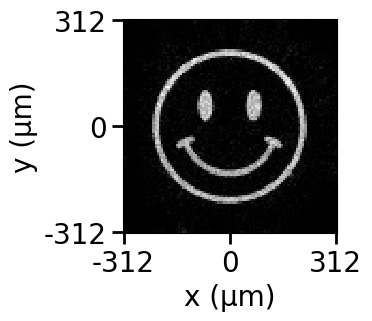

In [5]:
fig, ax = plt.subplots(figsize=(3.5, 3.5), facecolor="none")
ax.set_aspect("equal")
ax.pcolormesh(
    Xg.detach().cpu().numpy(),
    Yg.detach().cpu().numpy(),
    psf.detach().cpu().numpy(),
    cmap="gray",
)

xticks_um = np.linspace(Xg.min().detach().cpu().item(), Xg.max().detach().cpu().item(), 3) * 1000
yticks_um = np.linspace(Yg.min().detach().cpu().item(), Yg.max().detach().cpu().item(), 3) * 1000

ax.set_xticks(xticks_um / 1000)
ax.set_yticks(yticks_um / 1000)
ax.set_xticklabels([f"{v:.0f}" for v in xticks_um], fontsize=20)
ax.set_yticklabels([f"{v:.0f}" for v in yticks_um], fontsize=20)
ax.tick_params(axis="both", which="major", length=8, width=2, labelsize=20)

ax.set_xlabel("x (μm)", fontsize=20)
ax.set_ylabel("y (μm)", fontsize=20)

plt.tight_layout(pad=0)